# Phase 0: Set up (Runtime = 52s)

In [1]:
#Runtime = 45s
#Cell 1

# ============ BOOTSTRAP ============
import subprocess, sys, os
from google.colab import drive, userdata

# 1. Mount Google Drive
drive.mount('/content/drive')

# 2. Load credentials from Colab Secrets
TOKEN = userdata.get('gitToken')
NAME  = userdata.get('gitName')
EMAIL = userdata.get('gitMail')

# 3. Git identity
!git config --global user.name "{NAME}"
!git config --global user.email "{EMAIL}"

# 4. Clone repo (skip if already cloned)
REPO_DIR = '/content/mit808-2026-project-data-insight-drivers'
if not os.path.exists(REPO_DIR):
    !git clone https://{TOKEN}@github.com/up-mitc-ds/mit808-2026-project-data-insight-drivers.git
else:
    print("Repo already cloned")

# 5. Switch to your branch and sync with master
os.chdir(REPO_DIR)
!git checkout -b kc/tiling_pipeline
!git fetch origin master
!git merge origin/master -m "Sync with master"

# 6. Install dependencies
subprocess.check_call([
    sys.executable, '-m', 'pip', 'install', '-q', '-r',
    os.path.join(REPO_DIR, 'requirements.txt')
])

# 7. Make src/ importable and configure environment
sys.path.insert(0, REPO_DIR)
from src.setup import configure_environment, PATHS, save_and_push
configure_environment()

print("✅ Bootstrap complete — repo at", REPO_DIR)

# ============ IMPORTS ============
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import rasterio
import geopandas as gpd
import earthpy.plot as ep
import contextily as ctx
import laspy
import os
from rasterio.windows import Window

Mounted at /content/drive
Cloning into 'mit808-2026-project-data-insight-drivers'...
remote: Enumerating objects: 74, done.
remote: Counting objects: 100% (36/36), done.
remote: Compressing objects: 100% (32/32), done.
remote: Total 74 (delta 8), reused 24 (delta 4), pack-reused 38 (from 2)
Receiving objects: 100% (74/74), 9.21 MiB | 19.13 MiB/s, done.
Resolving deltas: 100% (11/11), done.
Switched to a new branch 'kc/tiling_pipeline'
From https://github.com/up-mitc-ds/mit808-2026-project-data-insight-drivers
 * branch            master     -> FETCH_HEAD
Already up to date.
✅ All 10 required packages available
✅ Plot defaults configured
✅ Output directories verified
────────────────────────────────────────
🚀 Environment ready
   Data:    /content/drive/MyDrive/MIT/MIT808/melusi-2025-data/raw/
   Repo:    /content/mit808-2026-project-data-insight-drivers
   Figures: /content/mit808-2026-project-data-insight-drivers/reports/figures
✅ Bootstrap complete — repo at /content/mit808-2026-proj

In [2]:
#Runtime = 0s
#Cell 2

!git status

On branch kc/tiling_pipeline
Changes not staged for commit:
  (use "git add <file>..." to update what will be committed)
  (use "git restore <file>..." to discard changes in working directory)
	modified:   src/__pycache__/__init__.cpython-312.pyc
	modified:   src/__pycache__/setup.cpython-312.pyc

no changes added to commit (use "git add" and/or "git commit -a")


In [3]:
#Runtime = 7s
#Cell 3

# osmnx for OSM road network download
# scipy for Voronoi computation
# Both should already be in requirements.txt — this is a safety install
!pip install tqdm -q
import scipy
from shapely.geometry import box
from tqdm import tqdm

In [4]:
# Paths
#Cell 4

IMAGE_PATH = "/content/drive/MyDrive/MIT/MIT808/melusi-2025-data/raw/Melusi_Georeferenced/Melusi_2025.tif"
GPKG_DIR = "/content/drive/MyDrive/MIT/MIT808/melusi-2025-data/processed/smoothBlocks/"
BLOCK_OUTPUT_DIR = "/content/drive/MyDrive/MIT/MIT808/melusi-2025-data/processed/smoothBlocks/block_rasters/"
TILE_OUTPUT_DIR = "/content/drive/MyDrive/MIT/MIT808/melusi-2025-data/processed/smoothBlocks/melusi_tiles/"


os.makedirs(BLOCK_OUTPUT_DIR, exist_ok=True)

os.makedirs(TILE_OUTPUT_DIR, exist_ok=True)

In [5]:
#Cell 5

from rasterio.mask import mask

#Phase 1: Load Blocks

In [7]:
#Cell 7

import pandas as pd
blocks_gdf = gpd.read_file(os.path.join(GPKG_DIR, "zone_boundaries_lo29.gpkg"))

with rasterio.open(IMAGE_PATH) as src:
    blocks_gdf = blocks_gdf.to_crs(src.crs)

print(f"Loaded {len(blocks_gdf)} blocks, CRS: {blocks_gdf.crs}")

# Match CRS to raster
with rasterio.open(IMAGE_PATH) as src:
    blocks_gdf = blocks_gdf.to_crs(src.crs)

Loaded 12 blocks, CRS: GEOGCS["Hartebeesthoek94",DATUM["Hartebeesthoek94",SPHEROID["WGS 84",6378137,298.257223563,AUTHORITY["EPSG","7030"]],AUTHORITY["EPSG","6148"]],PRIMEM["Greenwich",0],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]],AXIS["Latitude",NORTH],AXIS["Longitude",EAST],AUTHORITY["EPSG","4148"]]


# Stage A: Block Extraction

## Phase 2: Extract Block Rasters (RGBA)

In [8]:
#Cell 10

with rasterio.open(IMAGE_PATH) as src:

    for idx, row in tqdm(blocks_gdf.iterrows(), total=len(blocks_gdf)):

        block_geom = [row.geometry]
        block_id = f"block_{int(row['Blocks'])}"

        # Mask + crop — filled=False returns a masked array
        out_image, out_transform = mask(
            src,
            block_geom,
            crop=True,
            filled=False,
        )

        # Alpha from the mask (True = masked/outside polygon)
        alpha = (~out_image.mask[0] * 255).astype(np.uint8)

        # Fill masked pixels with 0 (black) and take RGB bands
        rgb = out_image.filled(0)[:3]

        rgba = np.vstack([rgb, alpha[np.newaxis, :, :]])

        out_path = os.path.join(BLOCK_OUTPUT_DIR, f"{block_id}.tif")

        with rasterio.open(
            out_path,
            "w",
            driver="GTiff",
            height=rgba.shape[1],
            width=rgba.shape[2],
            count=4,
            dtype=rgba.dtype,
            crs=src.crs,
            transform=out_transform,
        ) as dst:
            dst.write(rgba)

100%|██████████| 12/12 [07:44<00:00, 38.75s/it]


## Phase 3: Block Validation

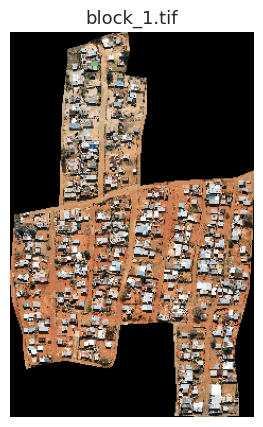

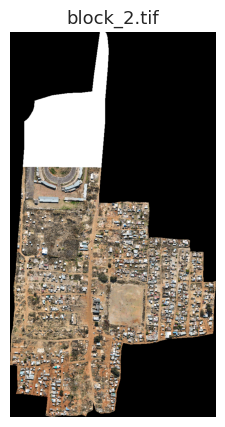

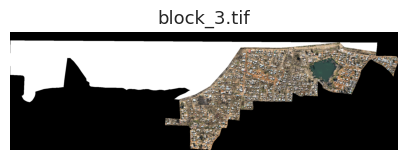

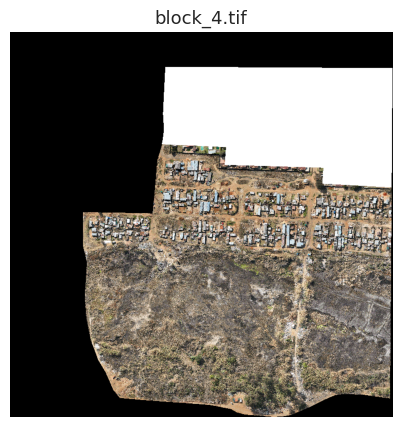

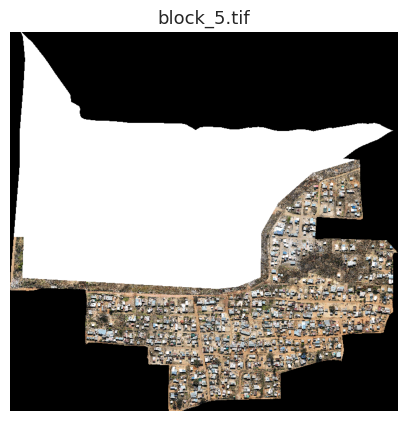

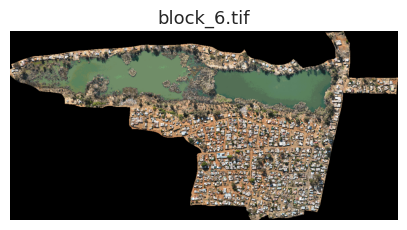

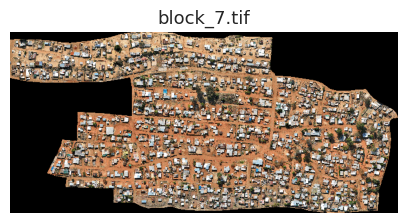

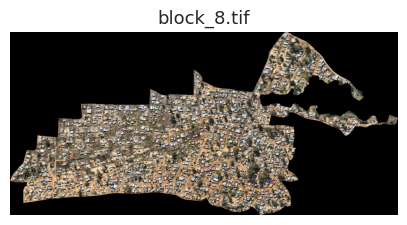

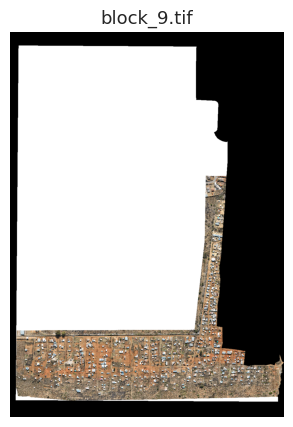

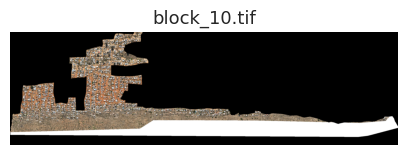

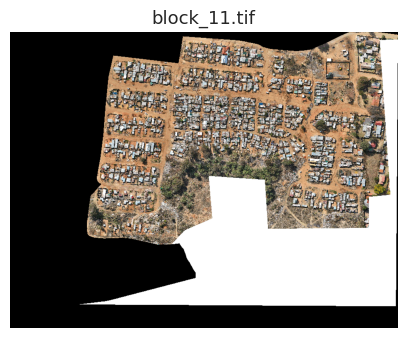

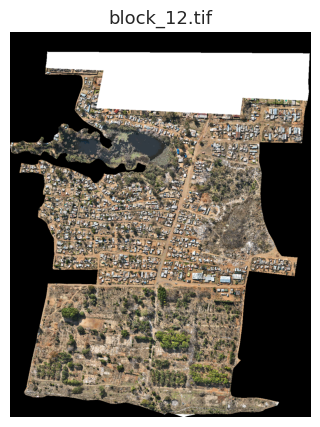

In [9]:
#Cell 12

def show_downsampled(path, factor=10):
    with rasterio.open(path) as src:

        new_height = max(1, src.height // factor)
        new_width = max(1, src.width // factor)

        img = src.read(
            out_shape=(
                src.count,
                new_height,
                new_width
            )
        )

    rgb = np.transpose(img[:3], (1,2,0)).astype(np.uint8)

    plt.figure(figsize=(5,5))
    plt.imshow(rgb)
    plt.title(os.path.basename(path))
    plt.axis('off')
    plt.show()

files = os.listdir(BLOCK_OUTPUT_DIR)

for f in files:
    if f.endswith(".tif"):
        show_downsampled(os.path.join(BLOCK_OUTPUT_DIR, f), factor=15)

In [10]:
#Cell 13

print(len(blocks_gdf))              # total geometries
print(blocks_gdf['Blocks'].nunique())  # unique blocks

12
12


In [11]:
#Cell 15

TILE_SIZE = 512
OVERLAP = 128
STRIDE = TILE_SIZE - OVERLAP  # 384

In [12]:
import json
from datetime import datetime, timezone

block_manifest = {
    "settlement": "Melusi",
    "created_utc": datetime.now(timezone.utc).isoformat(),
    "source_raster": os.path.basename(IMAGE_PATH),
    "tile_size_px": TILE_SIZE,
    "overlap_px": OVERLAP,
    "stride_px": STRIDE,
    "crs": None,
    "resolution_m": None,
    "blocks": []
}

for file in sorted(os.listdir(BLOCK_OUTPUT_DIR)):
    if not file.endswith(".tif"):
        continue

    block_id = file.replace(".tif", "")

    with rasterio.open(os.path.join(BLOCK_OUTPUT_DIR, file)) as src:
        block_manifest["crs"] = str(src.crs)
        block_manifest["resolution_m"] = round(abs(src.transform.a), 4)

        block_manifest["blocks"].append({
            "block_id": block_id,
            "width_px": src.width,
            "height_px": src.height,
            "area_m2": round(src.width * abs(src.transform.a) * src.height * abs(src.transform.e), 2),
            "bands": src.count,
            "dtype": str(src.dtypes[0]),
            "origin_x": src.transform.c,
            "origin_y": src.transform.f,
        })

manifest_path = os.path.join(BLOCK_OUTPUT_DIR, "block_manifest.json")
with open(manifest_path, "w") as f:
    json.dump(block_manifest, f, indent=2)

print(f"block_manifest.json written: {len(block_manifest['blocks'])} blocks")
for b in block_manifest["blocks"]:
    print(f"  {b['block_id']}: {b['width_px']}×{b['height_px']}px  |  {b['area_m2']:.0f} m²")

block_manifest.json written: 12 blocks
  block_1: 3450×5451px  |  0 m²
  block_10: 40226×11740px  |  0 m²
  block_11: 13609×10416px  |  0 m²
  block_12: 15170×19426px  |  0 m²
  block_2: 8674×16260px  |  0 m²
  block_3: 33479×10236px  |  0 m²
  block_4: 11814×11898px  |  0 m²
  block_5: 10770×10559px  |  0 m²
  block_6: 17885×8707px  |  0 m²
  block_7: 10175×4759px  |  0 m²
  block_8: 19240×9119px  |  0 m²
  block_9: 15232×21420px  |  0 m²


# Stage B: Tiling

## Phase 3: Filters

### Alpha layer Filter

In [13]:
#Cell 18

def is_mostly_transparent(tile, threshold=0.5):
    alpha = tile[3]
    return (alpha == 0).mean() > threshold

### Vegetation Filter

In [14]:
#Cell 20

def is_vegetation_dominant(tile, threshold=0.6):
    r, g, b = tile[0].astype(float), tile[1].astype(float), tile[2].astype(float)
    veg_mask = (g > r) & (g > b)
    return veg_mask.mean() > threshold

### Low Information Filter

In [15]:
#Cell 22

def is_low_variance(tile, threshold=10):
    return tile[:3].std() < threshold

### Padding

In [16]:
def read_padded_tile(src, x, y, tile_size):
    read_width = min(tile_size, src.width - x)
    read_height = min(tile_size, src.height - y)

    window = Window(x, y, read_width, read_height)
    data = src.read(window=window)

    if read_width == tile_size and read_height == tile_size:
        return data, read_width == tile_size and read_height == tile_size

    padded = np.zeros((src.count, tile_size, tile_size), dtype=data.dtype)
    padded[:, :read_height, :read_width] = data
    return padded, False

### No Data

In [17]:
def is_no_data(tile, threshold=0.5):
    """Catch tiles inside polygon but outside orthophoto coverage."""
    rgb = tile[:3]
    alpha = tile[3]
    inside = alpha == 255
    if inside.sum() == 0:
        return True
    # Inside pixels that are black (no imagery) or white (no imagery)
    black = np.all(rgb == 0, axis=0) & inside
    white = np.all(rgb > 250, axis=0) & inside
    empty = (black | white).sum() / inside.sum()
    return empty > threshold

## Phase 4: Tiling

In [18]:
def read_padded_tile(src, x, y, tile_size):
    read_width = min(tile_size, src.width - x)
    read_height = min(tile_size, src.height - y)

    window = Window(x, y, read_width, read_height)
    data = src.read(window=window)

    if read_width == tile_size and read_height == tile_size:
        return data, read_width == tile_size and read_height == tile_size

    padded = np.zeros((src.count, tile_size, tile_size), dtype=data.dtype)
    padded[:, :read_height, :read_width] = data
    return padded, False

In [19]:
import csv

tile_id = 0
stats = {"total": 0, "discarded": 0, "kept": 0}
tile_index_rows = []

for file in tqdm(sorted(os.listdir(BLOCK_OUTPUT_DIR))):
    if not file.endswith(".tif"):
        continue

    block_id = file.replace(".tif", "")

    with rasterio.open(os.path.join(BLOCK_OUTPUT_DIR, file)) as src:
        width, height = src.width, src.height
        transform = src.transform

        for y in range(0, height, STRIDE):
            for x in range(0, width, STRIDE):

                stats["total"] += 1

                tile, is_full = read_padded_tile(src, x, y, TILE_SIZE)
                tile_transform = rasterio.windows.transform(
                    Window(x, y, TILE_SIZE, TILE_SIZE), transform
                )

                # --- FILTER CASCADE ---
                filter_reason = None
                if is_no_data(tile):
                    filter_reason = "no_data"
                elif is_mostly_transparent(tile):
                    filter_reason = "transparent"
                elif is_low_variance(tile):
                    filter_reason = "low_variance"
                elif is_vegetation_dominant(tile):
                    filter_reason = "vegetation"

                kept = filter_reason is None

                tile_index_rows.append({
                    "tile_id": tile_id,
                    "block_id": block_id,
                    "x_offset": x,
                    "y_offset": y,
                    "res_x": tile_transform.a,
                    "res_y": tile_transform.e,
                    "origin_x": tile_transform.c,
                    "origin_y": tile_transform.f,
                    "kept": kept,
                    "padded": not is_full,
                    "filter_reason": filter_reason if filter_reason else "none",
                })

                if not kept:
                    stats["discarded"] += 1
                    tile_id += 1
                    continue

                out_path = os.path.join(
                    TILE_OUTPUT_DIR,
                    f"tile_{tile_id}_{block_id}.tif"
                )

                with rasterio.open(
                    out_path, "w", driver="GTiff",
                    height=TILE_SIZE, width=TILE_SIZE,
                    count=src.count, dtype=tile.dtype,
                    crs=src.crs, transform=tile_transform,
                ) as dst:
                    dst.write(tile)

                stats["kept"] += 1
                tile_id += 1

# --- WRITE tile_index.csv ---
tile_index_df = pd.DataFrame(tile_index_rows)
tile_index_df.to_csv(os.path.join(TILE_OUTPUT_DIR, "tile_index.csv"), index=False)

print(stats)
print(f"tile_index.csv: {len(tile_index_df)} rows ({stats['kept']} kept, {stats['discarded']} discarded)")

100%|██████████| 13/13 [1:45:21<00:00, 486.24s/it]


{'total': 16472, 'discarded': 11186, 'kept': 5286}
tile_index.csv: 16472 rows (5286 kept, 11186 discarded)


In [20]:
block_stats = (
    tile_index_df
    .groupby("block_id")
    .agg(
        total_tiles=("tile_id", "count"),
        kept_tiles=("kept", "sum"),
        discarded_tiles=("kept", lambda s: (~s).sum()),
        discard_rate=("kept", lambda s: round(1 - s.mean(), 3)),
    )
    .reset_index()
)

block_stats.to_csv(os.path.join(TILE_OUTPUT_DIR, "block_dwelling_counts.csv"), index=False)
print(block_stats.to_string(index=False))

block_id  total_tiles  kept_tiles  discarded_tiles  discard_rate
 block_1          135          74               61         0.452
block_10         3255         637             2618         0.804
block_11         1008         412              596         0.591
block_12         2040        1101              939         0.460
 block_2          989         408              581         0.587
 block_3         2376         490             1886         0.794
 block_4          961         435              526         0.547
 block_5          812         201              611         0.752
 block_6         1081         391              690         0.638
 block_7          351         227              124         0.353
 block_8         1224         502              722         0.590
 block_9         2240         408             1832         0.818


#Phase X: Git -push and -Commit

In [ ]:
save_and_push("kc_tiling_pipeline.ipynb", "Completed tiling and logs of process(1) Fixed Phase 3 CRS issue (2) Added logging to Phase 4 OSM download (3) Finalised Boundary definitions using Voronoi algorithm")